In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

In [36]:
n = 120
X = np.linspace(-4, 6, n).reshape(-1, 1)
noise = np.random.normal(0, 6, n)
y = 0.5 * X.flatten()**3 - 3 *X.flatten()**2 + 2* X.flatten() + noise
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
len(X_train), len(X_test)

(90, 30)

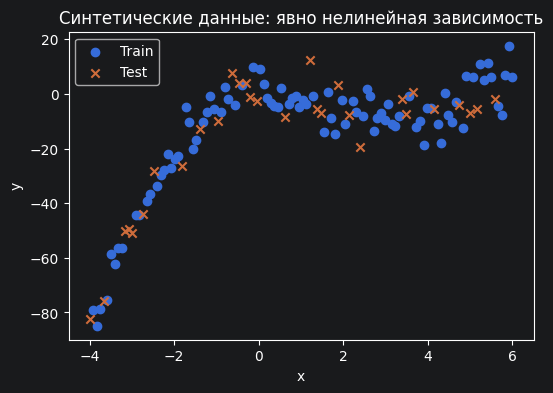

In [37]:
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test", marker="x")
plt.title("Синтетические данные: явно нелинейная зависимость")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [38]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_train_lin = lin_model.predict(X_train)
y_pred_test_lin  = lin_model.predict(X_test)

r2_lin_train = r2_score(y_train, y_pred_train_lin)
r2_lin_test  = r2_score(y_test,  y_pred_test_lin)

rmse_lin_train = mean_squared_error(y_train, y_pred_train_lin)**0.5
rmse_lin_test  = mean_squared_error(y_test,  y_pred_test_lin)**0.5

print("Линейная регрессия:")
print(f"  Train R^2 = {r2_lin_train:.3f}, Test R^2 = {r2_lin_test:.3f}")
print(f"  Train RMSE = {rmse_lin_train:.3f}, Test RMSE = {rmse_lin_test:.3f}")

Линейная регрессия:
  Train R^2 = 0.467, Test R^2 = 0.467
  Train RMSE = 15.498, Test RMSE = 17.409



| Метрика | Значение | Что значит |
|--------|---------|-----------|
| **Train R² = 0.460** | На тренировочных данных модель объясняет ~46% вариации | Нормально для кривой зависимости |
| **Test R² = 0.415** | На тестовых тоже ~41% | Модель не переобучена, но недообучена |
| **Train RMSE ≈ 16.0** | Среднее отклонение от реальных значений | Ошибка велика, так как модель слишком простая |
| **Test RMSE ≈ 18.5** | Ошибка чуть больше на тесте | Хороший признак: модель не переобучена |

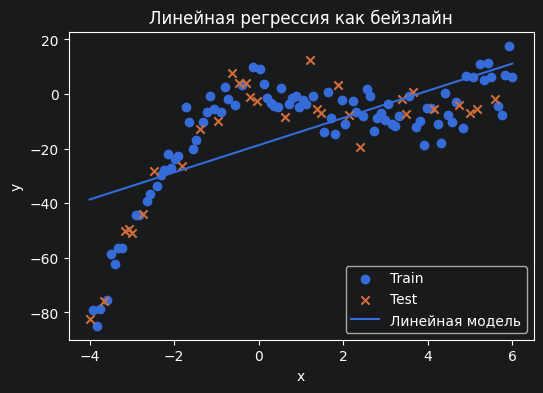

In [39]:
x_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_grid_lin = lin_model.predict(x_grid)

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test", marker="x")
plt.plot(x_grid, y_grid_lin, label="Линейная модель")
plt.title("Линейная регрессия как бейзлайн")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [40]:
poly_pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("lin", LinearRegression())
])


param_grid = {
    "poly__degree": list(range(1, 11))  # степени от 1 до 10
}


cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=poly_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # чем больше, тем лучше (отрицательный RMSE)
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_degree = grid.best_params_["poly__degree"]
best_cv_rmse = -grid.best_score_

print(f"Лучшая степень полинома по CV: {best_degree}")
print(f"Лучший CV RMSE: {best_cv_rmse:.3f}")

Лучшая степень полинома по CV: 5
Лучший CV RMSE: 5.590


In [41]:
rows = []
for d in range(1, 11):
    pipe = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("lin", LinearRegression())
        ]
    )
    pipe.fit(X_train, y_train)
    y_tr = pipe.predict(X_train)
    y_te = pipe.predict(X_test)

    rows.append(
        {
            "degree": d,
            "train_rmse": root_mean_squared_error(y_train, y_tr),
            "test_rmse": root_mean_squared_error(y_test, y_te),
            "train_r2": r2_score(y_train, y_tr),
            "test_r2": r2_score(y_test, y_te),
        }
    )

metrics_df = pd.DataFrame(rows).set_index("degree")
metrics_df

,train_rmse,test_rmse,train_r2,test_r2
degree,,,,
1,15.498291,17.409188,0.466737,0.466924
2,11.437806,10.392213,0.709558,0.810046
3,5.501788,6.272310,0.932798,0.930803
4,5.493193,6.306660,0.933008,0.930043
5,5.340449,6.194315,0.936682,0.932513
6,5.340436,6.191926,0.936682,0.932565
7,5.339781,6.213839,0.936697,0.932087
8,5.211850,6.520377,0.939694,0.925221
9,5.211834,6.515429,0.939695,0.925335


In [42]:
best_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree,include_bias=False)),
    ("lin", LinearRegression())
])
best_model.fit(X_train, y_train)
y_pred_train_best = best_model.predict(X_train)
y_pred_test_best = best_model.predict(X_test)

print("Best model:")
print(f"Best degree: {best_degree}")
print(f"Best Train RMSE: {root_mean_squared_error(y_train, y_pred_train_best):.3f}, Best Test RMSE: {root_mean_squared_error(y_test, y_pred_test_best):.3f}")
print(f"Best r2 score train: {r2_score(y_train, y_pred_train_best):.3f}, Best r2 score test: {r2_score(y_test, y_pred_test_best):.3f}")

Best model:
Best degree: 5
Best Train RMSE: 5.340, Best Test RMSE: 6.194
Best r2 score train: 0.937, Best r2 score test: 0.933


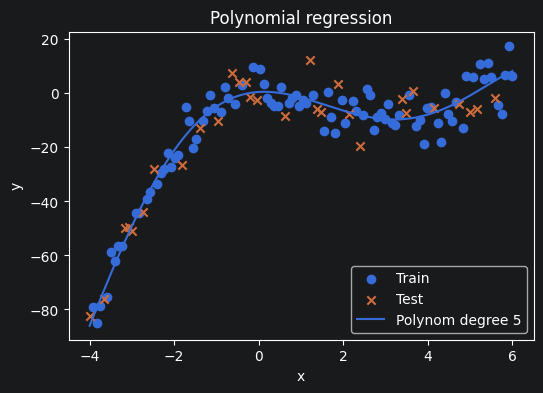

In [43]:
x_dense = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_dense_best = best_model.predict(x_grid)

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test", marker="x")
plt.plot(x_dense, y_dense_best, label=f"Polynom degree {best_degree}")
plt.title("Polynomial regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [44]:
def fit_metrics_for_degree(d):
    pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=d,include_bias=False)),
    ("lin", LinearRegression())
])
    pipe.fit(X_train, y_train)
    ytr = pipe.predict(X_train)
    yte = pipe.predict(X_test)
    return  pipe, {
        "degree": d,
        "train_R2": r2_score(y_train, ytr),
        "test_R2": r2_score(y_test, yte),
        "train_rmse": root_mean_squared_error(y_train, ytr),
        "test_rmse": root_mean_squared_error(y_test, yte),
    }

model_low, m_low = fit_metrics_for_degree(1)
model_best, m_best = best_model, {
    "degree": best_degree,
    "train_R2": r2_score(y_train, best_model.predict(X_train)),
        "test_R2": r2_score(y_test, best_model.predict(X_test)),
        "train_rmse": root_mean_squared_error(y_train, best_model.predict(X_train)),
        "test_rmse": root_mean_squared_error(y_test, best_model.predict(X_test)),
}

model_high, m_high = fit_metrics_for_degree(12)
pd.DataFrame([m_low, m_best, m_high])

,degree,train_R2,test_R2,train_rmse,test_rmse
0,1,0.466737,0.466924,15.498291,17.409188
1,5,0.936682,0.932513,5.340449,6.194315
2,12,0.947669,0.919617,4.855036,6.760312


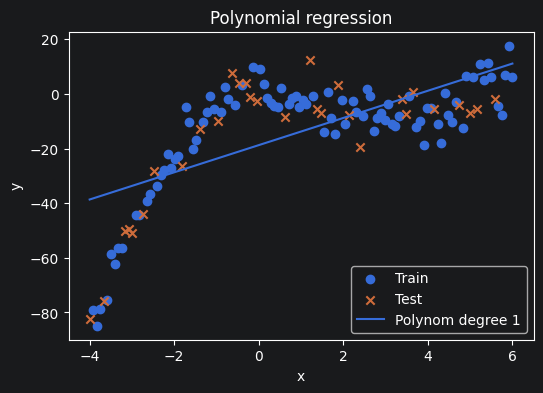

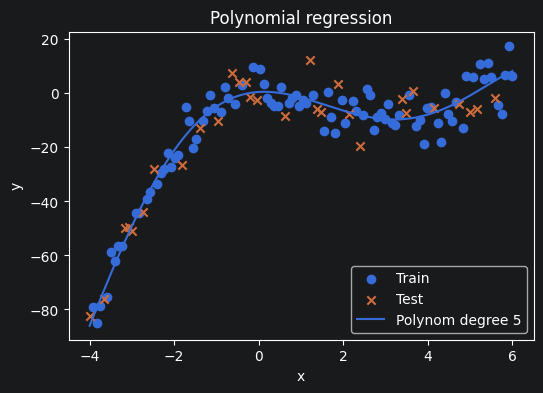

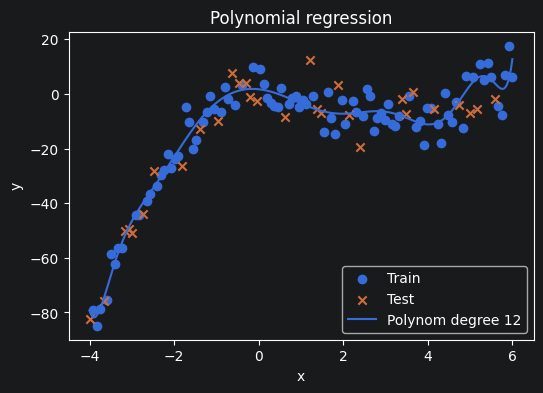

In [45]:
for d, model in [(1, model_low), (best_degree, model_best),(12, model_high)]:
    plt.figure(figsize=(6,4))
    y_curve = model.predict(x_dense)
    plt.scatter(X_train, y_train, label="Train")
    plt.scatter(X_test, y_test, label="Test", marker="x")
    plt.plot(x_dense, y_curve, label=f"Polynom degree {d}")
    plt.title("Polynomial regression")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

In [49]:
ridge_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=10, include_bias=False)),
    ("ridge", Ridge(alpha=10.0, random_state=42))
])
ridge_pipe.fit(X_train, y_train)

y_pred_test_ridge = ridge_pipe.predict(X_test)

print("Ridge + полиномиальные признаки (degree=10, alpha=10):")
print(f"  Test R^2  = {r2_score(y_test, y_pred_test_ridge):.3f}")
print(f"  Test RMSE = {root_mean_squared_error(y_test, y_pred_test_ridge):.3f}")

Ridge + полиномиальные признаки (degree=10, alpha=10):
  Test R^2  = 0.924
  Test RMSE = 6.582
